## Background
You have been hired as a junior data analyst in a leading financial institution specializing in offering personalized loan products to a wide range of customers. The company is looking to optimize its loan-granting process by leveraging data analytics to predict the loan amount that can be safely granted to applicants based on their demographic and financial details.
The goal is to develop a predictive model that can help the company make better decisions while minimizing risks. The dataset provided includes historical loan application data with key details such as the applicant’s credit score, monthly income, and the actual loan amount granted.
Your task is to identify a specific business problem related to loan data and develop a machine learning model to address the business problem identified.
Additionally, your insights and recommendations from this analysis will guide the company in refining its loan approval process and targeting customers more effectively.

## Objectives
1.
To analyze and preprocess the given dataset (loan_data.xlsx).
2.
To apply and interpret machine learning models for predicting key variable.
3.
To evaluate the performance of your machine learning model using statistical metrics.
4.
To articulate insights from the data analysis and provide recommendations for stakeholders.

## Dataset Overview
The dataset contains information on loan applicants. Key variables include:

* Loan Amount: The total loan amount granted to the borrower (in dollars).
* Income: The annual income of the borrower (in dollars).
* Credit Score: The borrower’s credit score, a numerical representation of creditworthiness.
* Loan Term: The loan repayment term in months.
* Interest Rate: The annual interest rate charged on the loan (in percentage).

## 1: Business Problem and Model Selection
- Identify and address a specific business problem related to loan data.
- Explore and compare the performance of different machine learning algorithms (e.g., k-means clustering, linear regression, decision trees - random forest).
- Recommend the most appropriate machine learning model based on its suitability and trade-offs for addressing the identified business problem.
- Provide a clear documentation of the business problem and a well-supported justification for the chosen machine learning model.

### Business Problem:
As a financial institution offering loan products to customers, the company would like to identify an appropriate loan amount to grant each individual based on certain factors/variables of that individual and the loan requested. Using the historical loan data, we can build a machine learning model to predict a suitable loan amount for future customers given their input variables. If this loan amount is efficiently predicted, the company can reduce their risk of losing money by minimising losses in the case of a loan default and maximising profits from the interest earned.

### Chosen machine learning model and justifications:
K-Means Clustering is an Unsupervised Machine Learning algorithm which groups unlabeled data into different clusters. It is used to organize data into groups based on their similarity. However our business problem is not a clustering problem, hence K-Means Clustering is not suitable.

Linear Regression is a Supervised Machine Learning algorithm that learns from labelled data and maps the data points with most optimized linear functions which can be used for prediction on new datasets. It computes the linear relationship between the dependent variable and one or more independent features by fitting a linear equation with observed data. It predicts the continuous output variables based on the independent input variable.

Random Forest is a Supervised Machine Learning algorithm that can be used in either Classification or Regression. In this case, our problem is a Regression problem so we will use Random Forest Regression. It operates by constructing multiple decision trees trained on different subsets of data and combining their predictions to output a value that is the mean prediction of the individual trees.

The business problem is a regression problem and the solution is to predict the loan amount, a quantitative variable, hence both Linear Regression and Random Forest Regression have potential to be used.

Since the provided historical training data only has 5 columns and the dataset size is relatively small (200 rows), we have decided to use Linear Regression due to its advantage in being easier to understand. If the dataset were larger and more complicated, Random Forest would be a more suitable choice. Linear Regression is simpler to interpret and explain how different factors affect the model. It also uses much less computational resources than Random Forest. One potential drawback is that Linear Regression models tend to only perform well based on the assumption of linearity among variables.

## 2: Data Preparation
- In the Excel data set, clean the data (if necessary) and perform data transformation (e.g., check data types are appropriate, etc)
- In the Excel data set, create at least ONE new feature / column related to your business problem. 
- Document the changes you have made to the data set (if any) and explain how this new feature could potentially enhance the model performance, based on domain knowledge.

In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel('C:/Users/cherw/Desktop/Projects/Loan Data Analysis/loan_data.xlsx')

In [2]:
df

,Loan_Amount,Income,Credit_Score,Loan_Term,Interest_Rate
0,19352.47,87782.85,572,60,3.17
1,47585.00,37572.60,361,48,7.72
2,36867.70,44546.58,641,24,5.45
3,30334.27,110869.88,696,12,1.99
4,8644.91,84578.62,318,24,1.00
...,...,...,...,...,...
195,18111.27,113768.16,634,24,1.49
196,36571.83,107257.15,841,48,3.00
197,44958.40,68609.46,405,12,6.16
198,44467.23,97578.40,380,60,5.89


In [3]:
#Check rows and columns
df.shape

(200, 5)

In [4]:
#Check for duplicates and remove
df = df.drop_duplicates().reset_index(drop = True)

In [5]:
df.shape
#No duplicates since rows and columns are the same

(200, 5)

In [6]:
#Check for NA values
df.isna().sum()
#No NA values

Loan_Amount      0
Income           0
Credit_Score     0
Loan_Term        0
Interest_Rate    0
dtype: int64

In [7]:
#Check for negative values
np.any(df.values < 0)
#No Negative Values

False

In [8]:
#Check if data types are appropriate
df.dtypes
#Data types are all numerical which is appropriate

Loan_Amount      float64
Income           float64
Credit_Score       int64
Loan_Term          int64
Interest_Rate    float64
dtype: object

## Feature Engineering
Based on domain knowledge, we know that there are many more factors which will contribute to the total loan amount granted for each individual. Income, Credit Score, Loan Term and Interest Rate alone will not be sufficient to determine an appropriate loan amount. As such we will attempt to feature engineer new columns that make some business sense and can potentially contribute to the predictive power of the model. Descriptions of each column will be included in the code comments below.

In [9]:
#New Feature "Loan_Term_Years" is simply "Loan_Term" divided by 12 which represents the loan repayment term in years. 
df['Loan_Term_Years'] = df['Loan_Term']/12

#New Feature "Interest" is simply "Interest_Rate" divided by 100 which represents the annual interest rate charged on the loan (as a fraction)
df['Interest'] = df['Interest_Rate']/100

#New Feature "Total_Interest" is calculated by multiplying "Loan_Amount", "Interest" and "Loan_Term_Years" which represents the total amount of profit
#the company will earn from the interest charged on the loan after the loan term. This is also the total additional amount that the customer has to pay
#on top of borrowing the loan.
df['Total_Interest'] = df['Loan_Amount'] * df['Interest'] * df['Loan_Term_Years']

#New Feature "Total_Loan_Amount" is the addition of "Loan_Amount" and "Total_Interest". This represents the total amount of money that the customer has
#to fork out and return over the course of the loan term.
df['Total_Loan_Amount'] = df['Loan_Amount'] + df['Total_Interest']

#New Feature "Total_Income" is "Income" multiplied by "Loan_Term_Years". This represents the total amount of money that the customer will earn from
#their income over the course of the loan term (assuming no increase in income annually).
df['Total_Income'] = df['Income'] * df['Loan_Term_Years']

#New Feature "Difficulty" is the "Total_Loan_Amount" divided by "Total_Income". This ratio is the sizing of the total loan amount relative to
#total income and somewhat reflects the ability of a customer to repay the loan based on their earning capability.
df['Difficulty'] = df['Total_Loan_Amount'] / df['Total_Income']

#df.sort_values(by=['Difficulty'])
df

,Loan_Amount,Income,Credit_Score,Loan_Term,Interest_Rate,Loan_Term_Years,Interest,Total_Interest,Total_Loan_Amount,Total_Income,Difficulty
0,19352.47,87782.85,572,60,3.17,5.0,0.0317,3067.366495,22419.836495,438914.25,0.051080
1,47585.00,37572.60,361,48,7.72,4.0,0.0772,14694.248000,62279.248000,150290.40,0.414393
2,36867.70,44546.58,641,24,5.45,2.0,0.0545,4018.579300,40886.279300,89093.16,0.458916
3,30334.27,110869.88,696,12,1.99,1.0,0.0199,603.651973,30937.921973,110869.88,0.279047
4,8644.91,84578.62,318,24,1.00,2.0,0.0100,172.898200,8817.808200,169157.24,0.052128
...,...,...,...,...,...,...,...,...,...,...,...
195,18111.27,113768.16,634,24,1.49,2.0,0.0149,539.715846,18650.985846,227536.32,0.081969
196,36571.83,107257.15,841,48,3.00,4.0,0.0300,4388.619600,40960.449600,429028.60,0.095473
197,44958.40,68609.46,405,12,6.16,1.0,0.0616,2769.437440,47727.837440,68609.46,0.695645
198,44467.23,97578.40,380,60,5.89,5.0,0.0589,13095.599235,57562.829235,487892.00,0.117983


In [10]:
#Save transformed dataset
df.to_excel('C:/Users/cherw/Desktop/Projects/Loan Data Analysis/loan_data_transformed.xlsx', index=False)

## 3: Exploratory Data Analysis (EDA)
- Load the provided dataset and conduct exploratory data analysis.
- Clearly document and explain your findings.

In [11]:
# import the necessary Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# Import StandardScaler for normalization
from sklearn.preprocessing import StandardScaler


In [12]:
#pd.options.display.max_rows = 999
df = pd.read_excel('C:/Users/cherw/Desktop/Projects/Loan Data Analysis/loan_data_transformed.xlsx')
df

,Loan_Amount,Income,Credit_Score,Loan_Term,Interest_Rate,Loan_Term_Years,Interest,Total_Interest,Total_Loan_Amount,Total_Income,Difficulty
0,19352.47,87782.85,572,60,3.17,5,0.0317,3067.366495,22419.836495,438914.25,0.051080
1,47585.00,37572.60,361,48,7.72,4,0.0772,14694.248000,62279.248000,150290.40,0.414393
2,36867.70,44546.58,641,24,5.45,2,0.0545,4018.579300,40886.279300,89093.16,0.458916
3,30334.27,110869.88,696,12,1.99,1,0.0199,603.651973,30937.921973,110869.88,0.279047
4,8644.91,84578.62,318,24,1.00,2,0.0100,172.898200,8817.808200,169157.24,0.052128
...,...,...,...,...,...,...,...,...,...,...,...
195,18111.27,113768.16,634,24,1.49,2,0.0149,539.715846,18650.985846,227536.32,0.081969
196,36571.83,107257.15,841,48,3.00,4,0.0300,4388.619600,40960.449600,429028.60,0.095473
197,44958.40,68609.46,405,12,6.16,1,0.0616,2769.437440,47727.837440,68609.46,0.695645
198,44467.23,97578.40,380,60,5.89,5,0.0589,13095.599235,57562.829235,487892.00,0.117983


In [13]:
#Summary statistics of the transformed data set, showing the count, mean, standard deviation, min and max, first, second and third quartiles
#of each column
df.describe()

,Loan_Amount,Income,Credit_Score,Loan_Term,Interest_Rate,Loan_Term_Years,Interest,Total_Interest,Total_Loan_Amount,Total_Income,Difficulty
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,24716.305200,75393.762300,563.935000,35.820000,3.793650,2.985000,0.037936,3378.758075,28095.063275,225312.060700,0.196622
std,14449.680199,26370.107722,159.701137,16.948269,1.880986,1.412356,0.018810,3800.054320,17400.759188,135413.465703,0.211189
min,1270.580000,30455.540000,300.000000,12.000000,1.000000,1.000000,0.010000,22.455400,1334.109000,30827.730000,0.002470
25%,12200.537500,53531.622500,429.500000,24.000000,2.275000,2.000000,0.022750,569.325293,13044.576665,116001.277500,0.054437
50%,25229.825000,78747.590000,544.500000,36.000000,3.715000,3.000000,0.037150,2200.424676,27412.162954,190164.430000,0.135895
75%,38086.125000,96797.942500,704.750000,48.000000,5.210000,4.000000,0.052100,4645.505736,41666.992200,317585.197500,0.246232
max,49357.460000,119145.460000,846.000000,60.000000,8.510000,5.000000,0.085100,20084.697790,67287.277790,595727.300000,1.550177


We will now investigate each column further via data visualisations to understand our data better. Boxplots and Histograms will be done for each column.

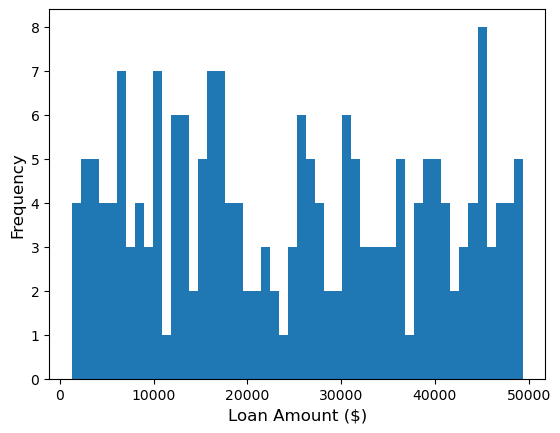

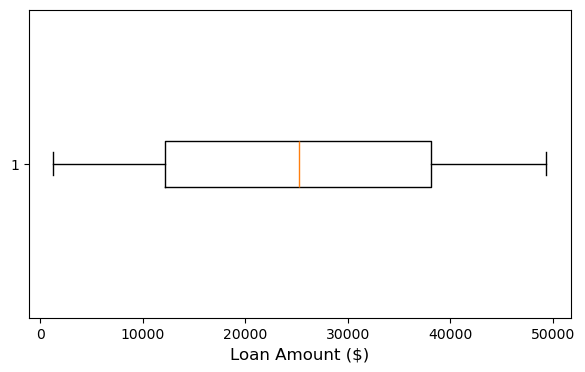

In [14]:
plt.hist(df['Loan_Amount'], bins=50)
plt.xlabel('Loan Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Loan_Amount'], vert=False)
plt.xlabel("Loan Amount ($)", fontsize=12)

plt.show()
#Loan Amount is randomly distributed, evenly spread out without any outliers present

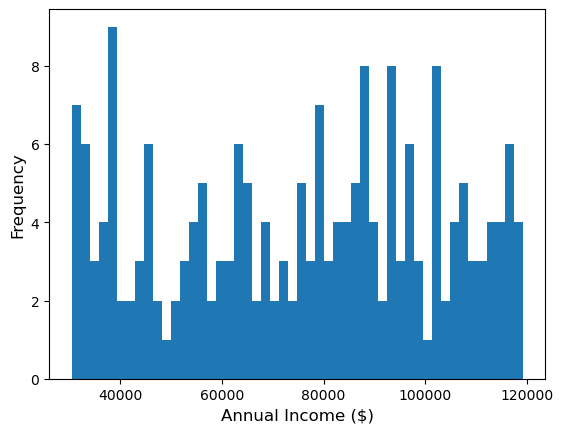

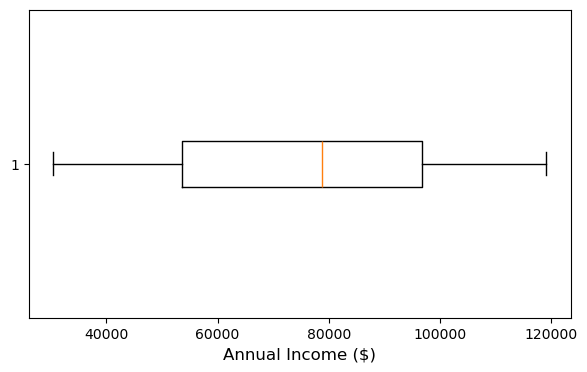

In [15]:
plt.hist(df['Income'], bins=50)
plt.xlabel('Annual Income ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Income'], vert=False)
plt.xlabel("Annual Income ($)", fontsize=12)

plt.show()
#Annual Income is randomly distributed, evenly spread out without any outliers present

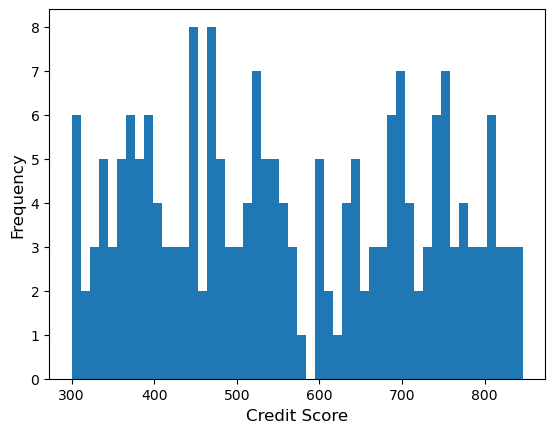

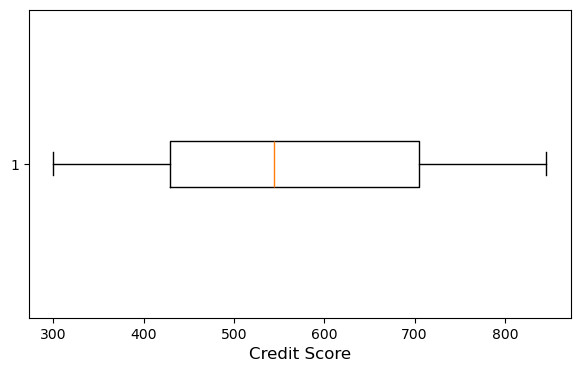

In [16]:
plt.hist(df['Credit_Score'], bins=50)
plt.xlabel('Credit Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Credit_Score'], vert=False)
plt.xlabel("Credit Score", fontsize=12)

plt.show()
#Credit Score is randomly distributed, evenly spread out without any outliers present

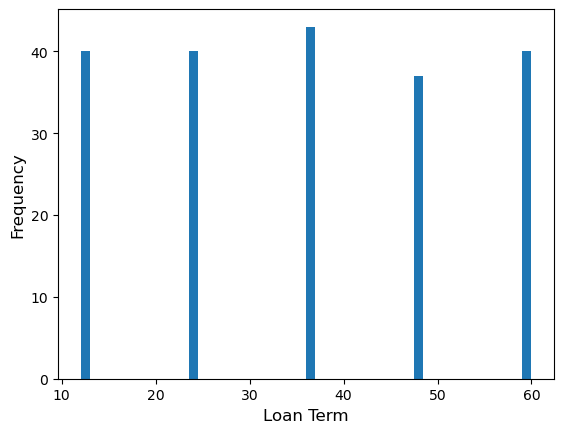

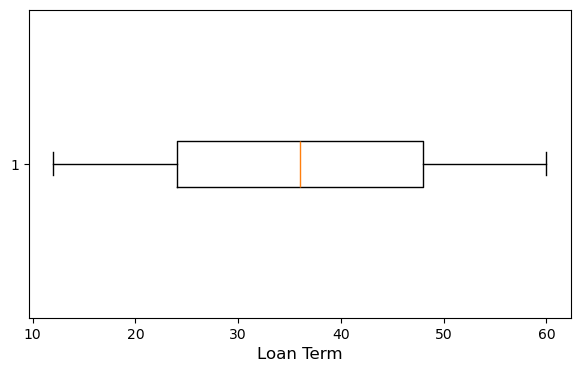

In [17]:
plt.hist(df['Loan_Term'], bins=50)
plt.xlabel('Loan Term', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Loan_Term'], vert=False)
plt.xlabel("Loan Term", fontsize=12)

plt.show()
#Loan Term is randomly distributed, evenly spread out without any outliers present
#Potentially 5 Categories (12, 24, 36, 48, 60)

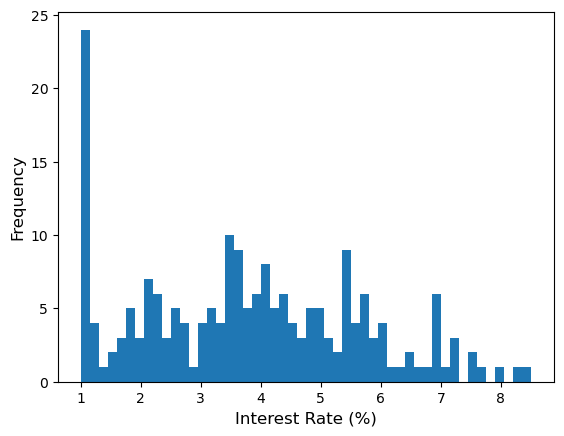

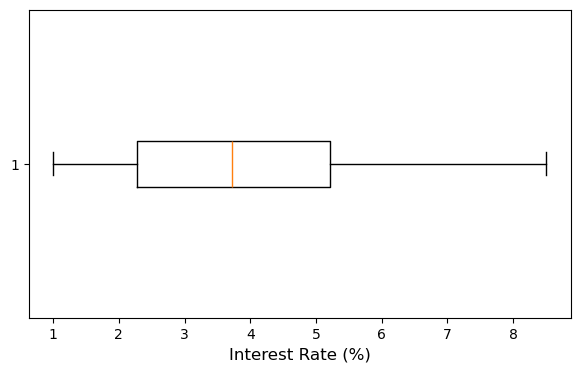

In [18]:
plt.hist(df['Interest_Rate'], bins=50)
plt.xlabel('Interest Rate (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Interest_Rate'], vert=False)
plt.xlabel("Interest Rate (%)", fontsize=12)

plt.show()
#Interest Rate is skewed to the right, without any outliers present
#High Frequency of 1% Interest Rates

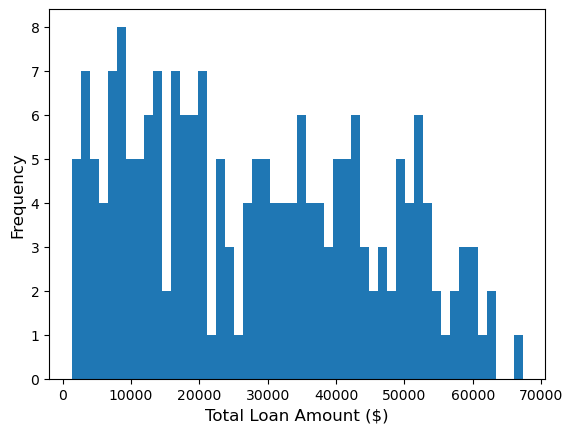

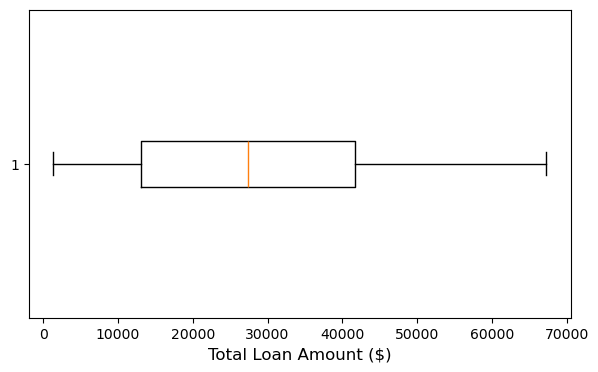

In [19]:
plt.hist(df['Total_Loan_Amount'], bins=50)
plt.xlabel('Total Loan Amount ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Total_Loan_Amount'], vert=False)
plt.xlabel("Total Loan Amount ($)", fontsize=12)

plt.show()
#Total Loan Amount is randomly distributed, evenly spread out without any outliers present

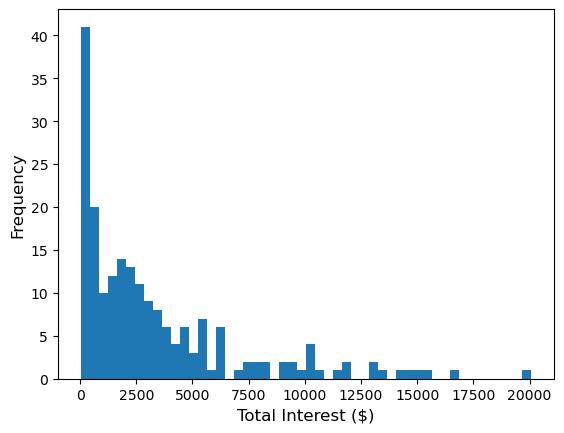

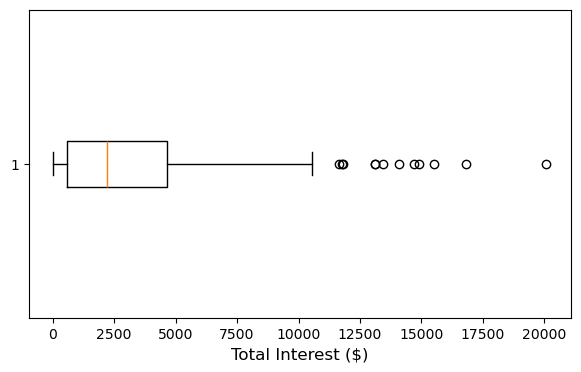

In [20]:
#Might have to log transform which will still have one outlier. Remove that outlier

plt.hist(df['Total_Interest'], bins=50)
plt.xlabel('Total Interest ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Total_Interest'], vert=False)
plt.xlabel("Total Interest ($)", fontsize=12)

plt.show()
#Total Interest is skewed to the right, with a few outliers present
#May have to log transform this column

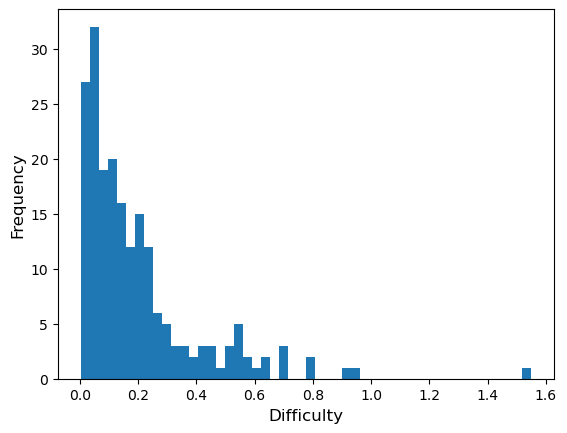

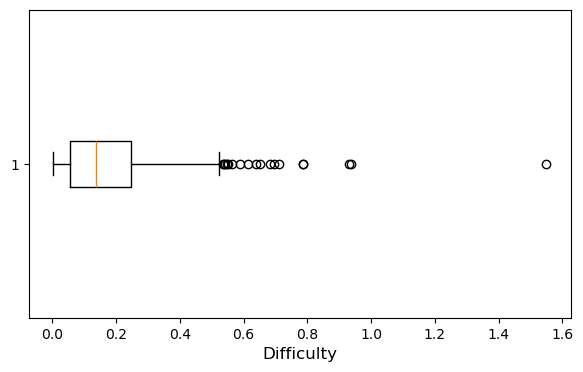

In [21]:
plt.hist(df['Difficulty'], bins=50)
plt.xlabel('Difficulty', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Difficulty'], vert=False)
plt.xlabel("Difficulty", fontsize=12)

plt.show()
#Difficulty is skewed to the right, with a few outliers present.
#There is one serious outlier (can consider removing)
#May have to log transform this column

### Data exploratory findings:
Boxplot and Histogram were plotted for columns 'Loan_Amount', 'Income', 'Credit_Score', 'Loan_Term', 'Interest_Rate', 'Total_Interest', 'Total_Loan_Amount' and 'Difficulty'.
- 'Loan_Term_Years' was left out because it is just 'Loan_Term' divided by 12
- 'Interest' was left out because it is just 'Interest_Rate' divided by 100
- 'Total_Income' was left out because it is just 'Income' multiplied by 'Loan_Term_Years'

The columns that were investigated are all generally well distributed and without anomalies. With the exception of 'Total_Interest' and 'Difficulty' showing right skewed distributions and multiple outliers. These may potentially affect the model and might have to revisit and address in the later part.

## 4: Analyzing Variable Correlations
- Create visualizations to illustrate the relationships between variable(s).
- Analyze for multicollinearity among variables (if needed).
- Document and explain your findings

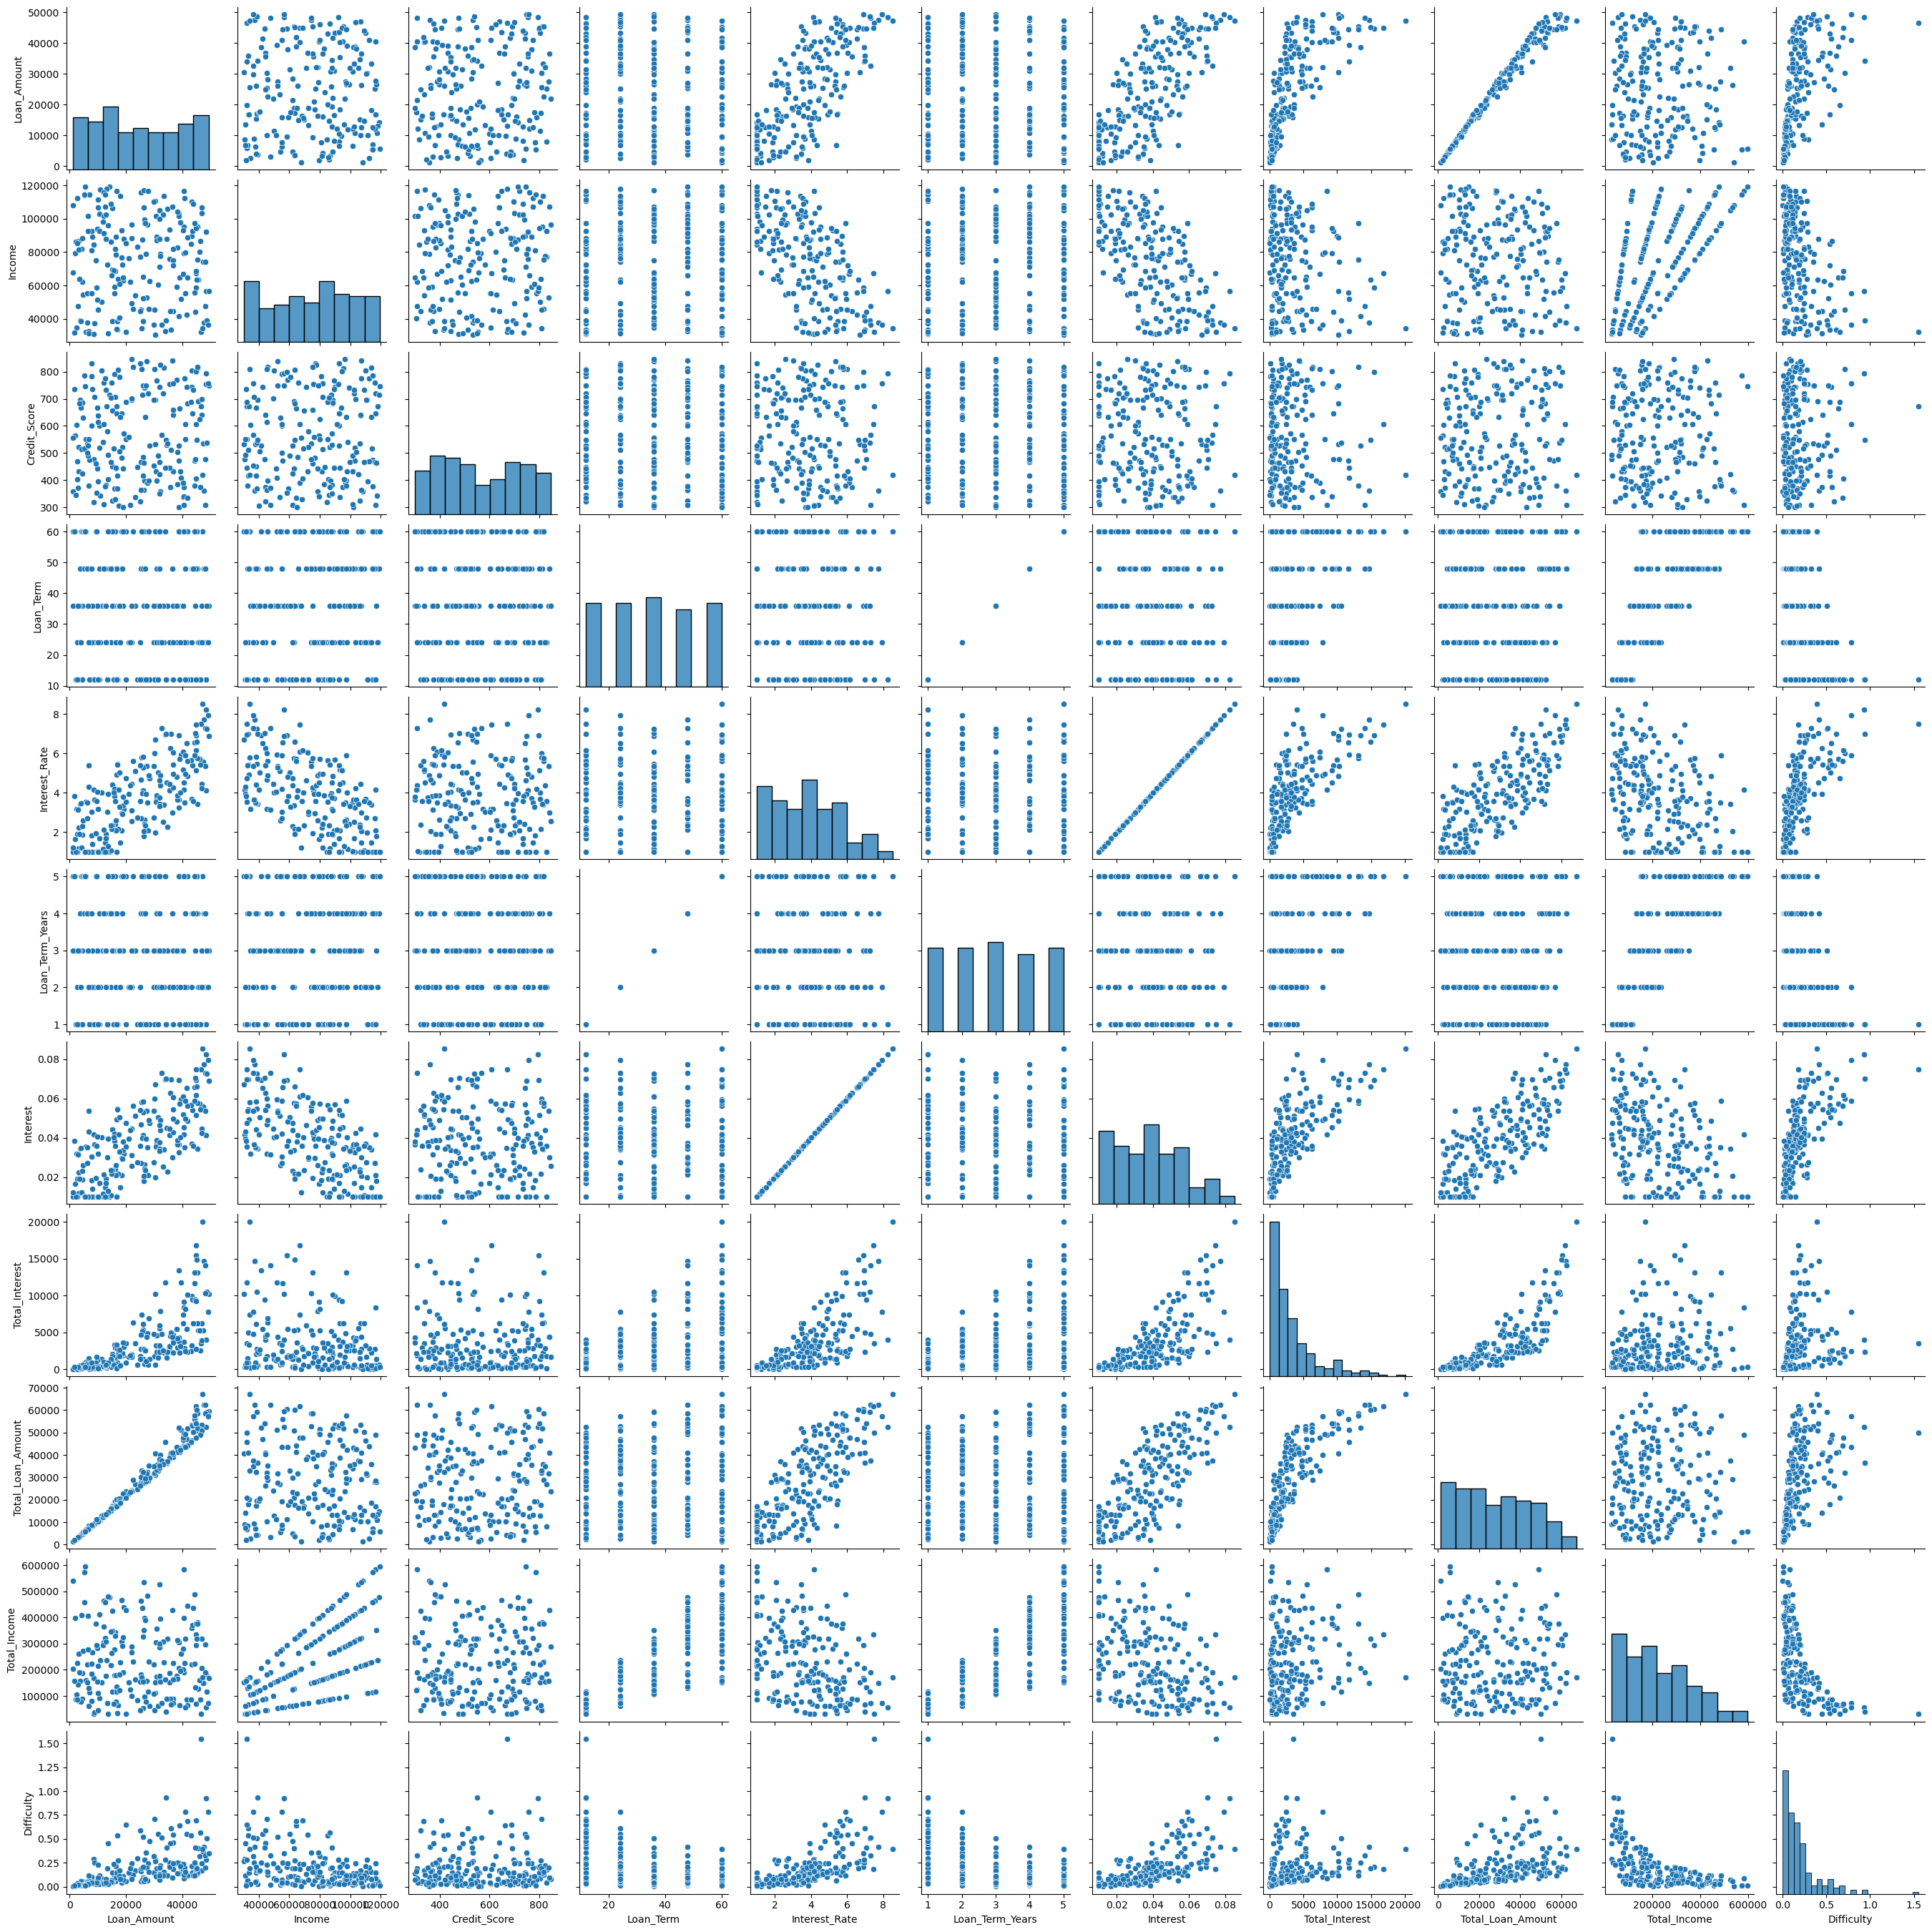

In [22]:
#Scatter plot for each pair of variables in the dataset
sns.pairplot(df)

In [23]:
#Note: exclude highly correlated variables but choose a variable correlated to target variable
#Correlation Matrix showing the Correlation Coefficient (r) values between each variable
df.corr()

,Loan_Amount,Income,Credit_Score,Loan_Term,Interest_Rate,Loan_Term_Years,Interest,Total_Interest,Total_Loan_Amount,Total_Income,Difficulty
Loan_Amount,1.000000,-0.026887,0.072446,-0.027813,0.730929,-0.027813,0.730929,0.724398,0.988602,-0.033020,0.553938
Income,-0.026887,1.000000,0.054595,0.007061,-0.644552,0.007061,-0.644552,-0.242318,-0.075246,0.589268,-0.429243
Credit_Score,0.072446,0.054595,1.000000,-0.044273,-0.018862,-0.044273,-0.018862,-0.030478,0.053503,0.004064,0.051387
Loan_Term,-0.027813,0.007061,-0.044273,1.000000,0.003652,1.000000,0.003652,0.435420,0.071993,0.765359,-0.500911
Interest_Rate,0.730929,-0.644552,-0.018862,0.003652,1.000000,0.003652,1.000000,0.723258,0.764916,-0.368206,0.678398
Loan_Term_Years,-0.027813,0.007061,-0.044273,1.000000,0.003652,1.000000,0.003652,0.435420,0.071993,0.765359,-0.500911
Interest,0.730929,-0.644552,-0.018862,0.003652,1.000000,0.003652,1.000000,0.723258,0.764916,-0.368206,0.678398
Total_Interest,0.724398,-0.242318,-0.030478,0.435420,0.723258,0.435420,0.723258,1.000000,0.819928,0.157678,0.202381
Total_Loan_Amount,0.988602,-0.075246,0.053503,0.071993,0.764916,0.071993,0.764916,0.819928,1.000000,0.007014,0.504190
Total_Income,-0.033020,0.589268,0.004064,0.765359,-0.368206,0.765359,-0.368206,0.157678,0.007014,1.000000,-0.569546


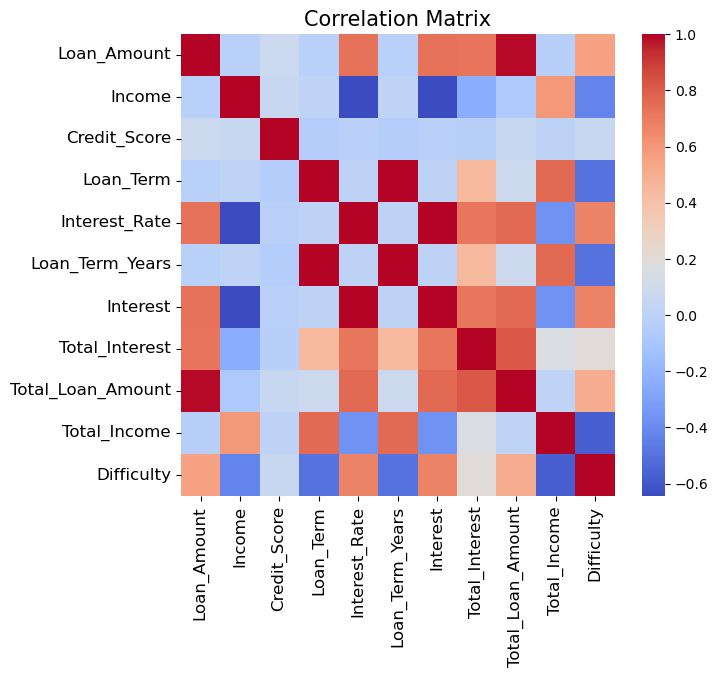

In [24]:
#Heatmap of the Correlation Matrix
plt.figure(figsize=(7,6))

corrMatrix = df.corr()
sns.heatmap(corrMatrix, cmap='coolwarm')

plt.title('Correlation Matrix', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

### Variable correlations findings:
- Loan_Amount vs Interest_Rate: positive correlation observed
- Interest_Rate has high correlation with independent variables Interest, Total_Interest and Total_Loan_Amount.
- Loan_Term has high correlation with independent variables Loan_Term_Years and Total_Income.
- To avoid multicollinearity, we will remove Interest, Total_Interest, Total_Loan_Amount, Loan_Term_Years and Total_Income.

In [33]:
df = df.drop(columns=['Interest', 'Total_Interest', 'Total_Loan_Amount', 'Loan_Term_Years', 'Total_Income'])
df

,Loan_Amount,Income,Credit_Score,Loan_Term,Interest_Rate,Difficulty
0,19352.47,87782.85,572,60,3.17,0.051080
1,47585.00,37572.60,361,48,7.72,0.414393
2,36867.70,44546.58,641,24,5.45,0.458916
3,30334.27,110869.88,696,12,1.99,0.279047
4,8644.91,84578.62,318,24,1.00,0.052128
...,...,...,...,...,...,...
195,18111.27,113768.16,634,24,1.49,0.081969
196,36571.83,107257.15,841,48,3.00,0.095473
197,44958.40,68609.46,405,12,6.16,0.695645
198,44467.23,97578.40,380,60,5.89,0.117983


In [34]:
df.corr()

,Loan_Amount,Income,Credit_Score,Loan_Term,Interest_Rate,Difficulty
Loan_Amount,1.000000,-0.026887,0.072446,-0.027813,0.730929,0.553938
Income,-0.026887,1.000000,0.054595,0.007061,-0.644552,-0.429243
Credit_Score,0.072446,0.054595,1.000000,-0.044273,-0.018862,0.051387
Loan_Term,-0.027813,0.007061,-0.044273,1.000000,0.003652,-0.500911
Interest_Rate,0.730929,-0.644552,-0.018862,0.003652,1.000000,0.678398
Difficulty,0.553938,-0.429243,0.051387,-0.500911,0.678398,1.000000


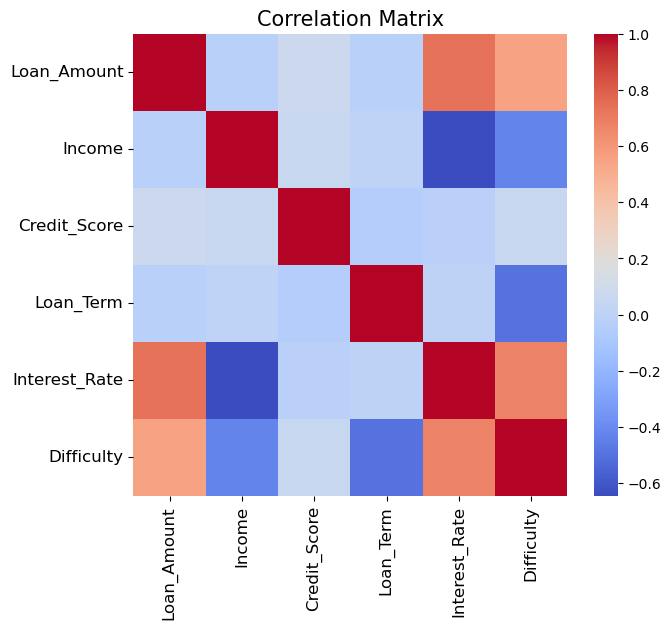

In [35]:
#Heatmap of the Correlation Matrix
plt.figure(figsize=(7,6))

corrMatrix = df.corr()
sns.heatmap(corrMatrix, cmap='coolwarm')

plt.title('Correlation Matrix', fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.show()

## 5: Develop the Machine Learning Model
- Build a machine learning model related to your business problem.
- You can select as many independent variable(s) as needed 
- Document the model-building process with explanations, why certain variables are chosen / not chosen.

In [36]:
# Define independent (x) and dependent (y) variables
x = df[['Income', 'Credit_Score', 'Loan_Term', 'Interest_Rate', 'Difficulty']]
y = df['Loan_Amount']

# Split the dataset into training and testing sets (75% training data, 25% test data)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=23)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [37]:
#Y-Intercept
print(model.intercept_)

-44136.24011556643


In [38]:
#Regression Coefficients
coeff_df = pd.DataFrame(model.coef_, x.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Income,0.417974
Credit_Score,1.755253
Loan_Term,30.465639
Interest_Rate,8984.253028
Difficulty,6213.605634


### Model building explanations:
The Linear Regression Model that was fitted has the equation: <br>
Loan_Amount = -44136.24 + 0.42Income + 1.76Credit_Score + 30.47Loan_Term + 8984.25Interest_Rate + 6213.61Difficulty <br>
Independent Variables Interest, Total_Interest, Total_Loan_Amount, Loan_Term_Years and Total_Income were not selected to prevent multicollinearity in our model.

## 6: Model Optimization
- Improve model accuracy through techniques like feature selection or other adjustments.
- Justify the choice of features based on domain knowledge or data insights.
- Document and justify every modification made, based on domain knowledge, to enhance the model performance.

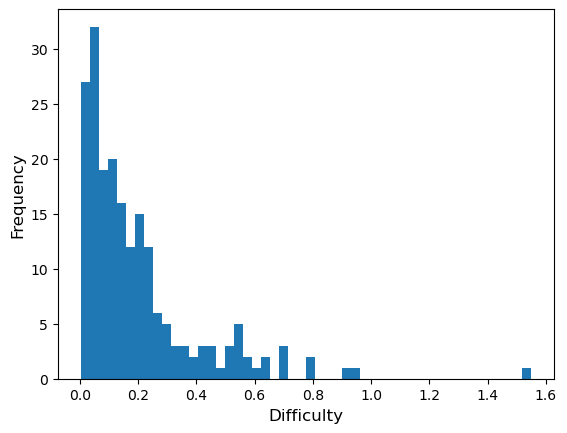

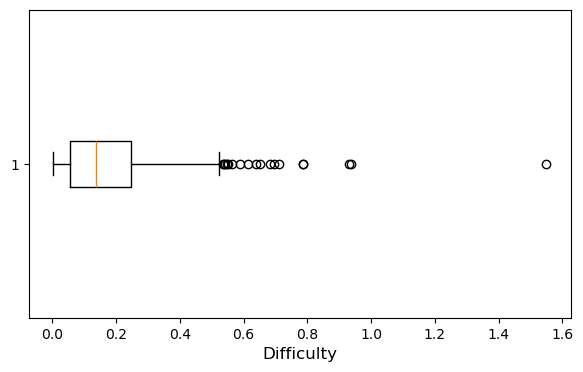

In [39]:
#Previously we noticed that the column 'Difficulty' has a right-skewed distribution and some serious outliers
#which is not desirable since we are including it in our model.

plt.hist(df['Difficulty'], bins=50)
plt.xlabel('Difficulty', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Difficulty'], vert=False)
plt.xlabel("Difficulty", fontsize=12)

plt.show()

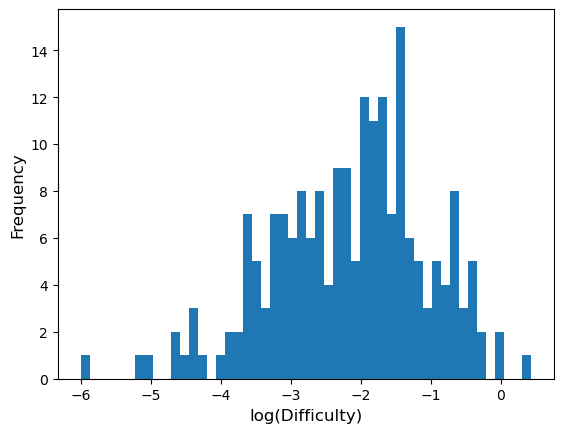

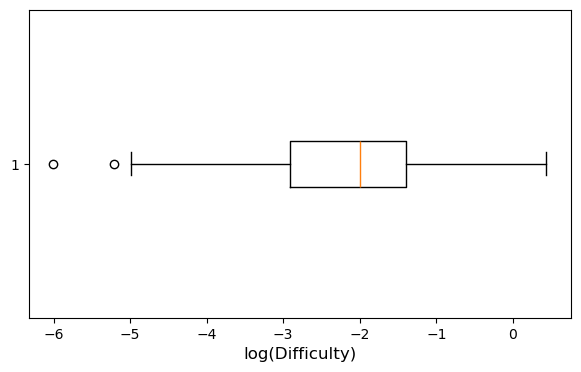

In [40]:
#A logarithm transformation on 'Difficulty' may be useful when fitting the regression model. By doing the logarithm transformation, the data 
#distribution for 'Difficulty' is now more symmetrical (bell-shaped or normal distribution) and minimizes outliers, which are now, not far              
#away from the data center.

df['Difficulty'] = np.log(df['Difficulty'])

plt.hist(df['Difficulty'], bins=50)
plt.xlabel('log(Difficulty)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Difficulty'], vert=False)
plt.xlabel("log(Difficulty)", fontsize=12)

plt.show()

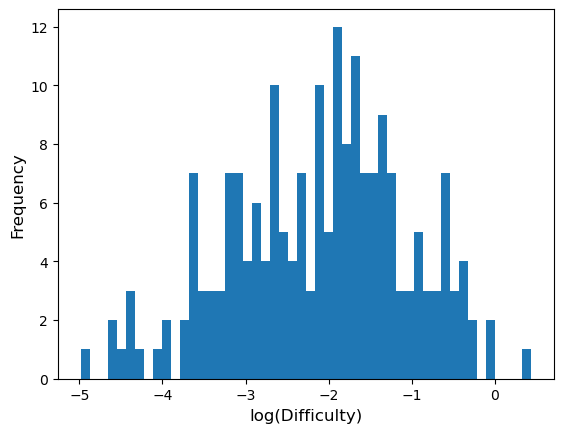

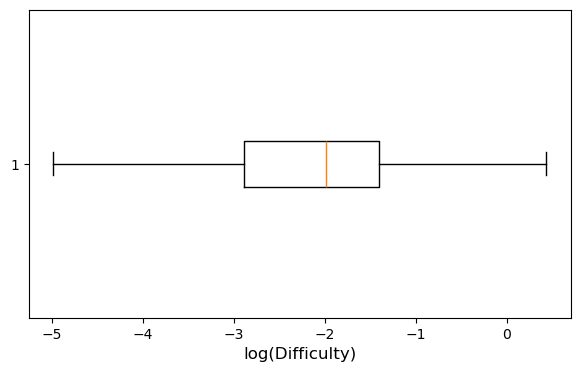

In [41]:
#Based on the boxplot, there are still 2 outliers present after the log transformation on Difficulty. We will remove them.

df = df.drop(df.nsmallest(2, 'Difficulty').index)

plt.hist(df['Difficulty'], bins=50)
plt.xlabel('log(Difficulty)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.figure(figsize=(7,4))
plt.boxplot(df['Difficulty'], vert=False)
plt.xlabel("log(Difficulty)", fontsize=12)

plt.show()

In [42]:
#Refit Model with transformed data
x = df[['Income', 'Credit_Score', 'Loan_Term', 'Interest_Rate', 'Difficulty']]
y = df['Loan_Amount']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=23)

model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

## 7: Model Performance Evaluation
- Evaluate the model performance using appropriate metrics.
- Discuss how these metrics provide insight into model accuracy and prediction reliability.

In [44]:
# Make predictions on the test set
y_pred = model.predict(x_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 22760124.470417246
R-squared: 0.8904933714008954


### Model performance findings:
R-squared value is the percentage of the dependent variable (Loan_Amount) variation that our Linear Model explains. Higher R-squared values represent smaller differences between the observed data and fitted values. The R-squared value for our model is 0.89 which is quite close to 1 and represents a good fit of the linear regression model. <br>
However, Mean Squared Error is very high which is likely due to the difference in scales of our variables. We will attempt to standardize the data to reduce this error.


## Standardize Data to reduce MSE
Based on the initial fitted model, the Mean Squared Error was very high (22760124.47). This can be improved by standardizing the data before fitting the model.

In [45]:
scaler = StandardScaler() 

df[df.columns] = scaler.fit_transform(df)

df

,Loan_Amount,Income,Credit_Score,Loan_Term,Interest_Rate,Difficulty
0,-0.391468,0.477514,0.044035,1.452566,-0.346969,-0.805959
1,1.583207,-1.429268,-1.279483,0.738898,2.087486,1.166155
2,0.833604,-1.164424,0.476844,-0.688437,0.872934,1.262294
3,0.376635,1.354266,0.821837,-1.402105,-0.978322,0.793635
4,-1.140389,0.355830,-1.549204,-0.688437,-1.508016,-0.786833
...,...,...,...,...,...,...
195,-0.478281,1.464331,0.432936,-0.688437,-1.245844,-0.360417
196,0.812910,1.217069,1.731363,0.738898,-0.437926,-0.216759
197,1.399494,-0.250614,-1.003489,-1.402105,1.252816,1.654163
198,1.365140,0.849509,-1.160303,1.452566,1.108354,-0.017326


In [46]:
#Refit model with standardized data
x = df[['Income', 'Credit_Score', 'Loan_Term', 'Interest_Rate', 'Difficulty']]
y = df['Loan_Amount']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=23)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 0.11134385954908359
R-squared: 0.8904933714008955


Scaling the data before fitting the model helped greatly reduced the MSE while maintaining a good R-squared value.

In [ ]:
# # Initialize and train the Random Forest model
# model = RandomForestRegressor(n_estimators=100)
# model.fit(x_train, y_train)

# # Make predictions on the test set
# y_pred = model.predict(x_test)

# # Evaluate the model
# mse = mean_squared_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print(f"Mean Squared Error: {mse}")
# print(f"R-squared: {r2}")

## 8: Insights and Recommendations
- Generate and Interpret the model results, identifying trends and implications in the context of loan application.
- Connect the interpretations of the model results to real-world banking decisions (e.g., why would a specific variable impact the loan amount significantly).

In [47]:
#Y-Intercept
print(model.intercept_)

0.010828262682905612


In [48]:
#Regression Coefficients
coeff_df = pd.DataFrame(model.coef_, x.columns, columns=['Coefficient'])
coeff_df

,Coefficient
Income,0.658293
Credit_Score,0.019316
Loan_Term,0.204879
Interest_Rate,0.767802
Difficulty,0.501677


### Interpretations of model results:

After some data transformations and scaling, our final Linear Regression Model has the equation: <br>
Loan_Amount = 0.01 + 0.66Income + 0.02Credit_Score + 0.20Loan_Term + 0.77Interest_Rate + 0.50log(Difficulty) <br>

The R-squared of our model is high (0.89) and MSE is low (0.11) which indicates that our assumption of linearity holds and our business problem can be effectively explained by a linear model.

Previously it was observed that Interest_Rate had a high correlation with Loan_Amount. Based on domain knowledge, this makes sense because the greater the loan amount, the higher the interest rate should be charged to reduce the higher risks involved. <br>
We also understand that the Income and Credit Score of an individual somewhat determines their financial status and earning capability. These will provide measures of confidence to a loan company and allow them to safely grant a higher loan to individuals with higher income and credit scores since these individuals will be less likely to default on the loan.

## 9: Conclusion
- Explain how your model may be used for prediction / interpretation.
- Discuss model limitations and propose actionable recommendations based on your findings.
- Recommend changes to improve the model's accuracy.


Using our final model equation: __Loan_Amount = 0.01 + 0.66Income + 0.02Credit_Score + 0.20Loan_Term + 0.77Interest_Rate + 0.50log(Difficulty)__ <br>
Given a new customer that is intending to apply for a loan with our company, we can calculate and predict a suitable loan amount to grant that individual. For example, a customer with Income = 87000, Credit Score = 570, Loan Term = 60, Interest Rate = 3 and Difficulty = 0.5 can be efficiently granted a Loan Amount of $57445.37. This equation can be easily used for any new customers to ensure the company can maximise their profits and reduce risks. We only need to ensure we obtain the information from the customers required for the independent variable inputs. <br>

Some of our model limitations are that it was trained on a very small dataset with few columns and rows. It can be more accurate and consistent if we had access to a larger database of customers. This will also reduce the biasness of the model. Based on domain knowledge, we know that there are many other factors which can contribute to an individual's ability to repay a loan which in turn affects the maximum profit the company can gain from each individual. Some factors that can be included into our model to improve accuracy and interpritability are the demographics of individual customers like their family size, number of children, whether they are single/married/divorced, their race, age, years of working experience and their field of profession. Another limitation is that the additional feature we created (Difficulty) that was used in the model, was calculated using the target variable and in reality may not be an easily obtainable value or may not exist at all. If we can use more variables that make sense in real life, it would be better for the model.

In conclusion, we were able to fit a good predictive model and made sure to reduce bias as much as we could

In [49]:
0.01 + 0.66*87000 + 0.02*570 + 0.20*60 + 0.77*3 + 0.50*np.log(0.5)

57445.37342640972